# willhaben listings to synthetic dataset

## Imports

In [2]:
import pandas as pd
import numpy as np
import pyproj
import shapely
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#imports
df = pd.read_csv("gemini_listings.csv")

df_copy = df.copy           #clean copy

## Basic Checks (nulls, data types)

In [6]:
df.dtypes

ID            int64
District      int64
Title           str
Price           str
Size          int64
Rooms       float64
Features        str
Seller          str
dtype: object

In [7]:
#checking for null values
df.isnull().sum()

ID           0
District     0
Title        0
Price        0
Size         0
Rooms        0
Features    64
Seller       0
dtype: int64

In [4]:
#Price: remove characters, then turn to int

df['Price'] = df['Price'].str.replace('.', '')
df['Price'] = df['Price'].str.replace('€', '')

df['Price'] = df['Price'].astype(int)

In [5]:
#turn columns lower case

df.columns = df.columns.str.lower()
df.head()

,id,district,title,price,size,rooms,features,seller
0,1,1,Charmanter Altbau im Herzen der Inneren Stadt,1100000,107,3.0,Altbau,Commercial
1,2,1,Exklusive Dachgeschosswohnung nahe Stephansplatz,2850000,124,3.0,"Terrasse, Lift",Commercial
2,3,1,Stilvoller Altbaucharme Schottenring,1490000,88,2.0,"Altbau, Lift",Commercial
3,4,1,Wunderschöne ERSTBEZUG 4 Zi Wohnung Innere Stadt,1950000,118,4.0,"Erstbezug, Terrasse",Commercial
4,5,1,Luxus-Apartment Ringstraße mit Blick auf die Oper,3400000,140,4.0,"Lift, Klimaanlage",Commercial


In [41]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,230.0,115.500000,66.539462,1.0,58.25,115.5,172.75,230.0
district,230.0,12.000000,6.647717,1.0,6.00,12.0,18.00,23.0
price,230.0,572394.160870,591918.243976,79000.0,252025.00,399000.0,641750.00,4890000.0
size,230.0,76.556522,54.934688,17.0,47.25,68.0,92.00,713.0
rooms,230.0,2.504348,1.081798,1.0,2.00,2.0,3.00,9.0


## adding features: price/sqm, turning features binary

In [6]:
#adding price per squaremeter

df['price/sqm'] = df['price'] / df['size']

In [7]:
#turning features binary
feature_dummies = df['features'].str.get_dummies(sep=', ')
df = pd.concat([df, feature_dummies], axis=1)

In [8]:
#listing all the features i have to see if i need to consolidate
df['features'].str.split(', ').explode().unique()

<StringArray>
[      'Altbau',     'Terrasse',         'Lift',    'Erstbezug',
  'Klimaanlage',   'Hohe Räume', 'Dachterrasse',            nan,
       'Balkon',       'Loggia',       'Garten',    'Terrassen',
 'Wintergarten']
Length: 13, dtype: str

In [ ]:
#combining "terrasse"
df['Terrasse'] = df['Terrasse'] + df['Terrassen']
df = df.drop(columns=['Terrassen'])

In [10]:
#lowering column headers again
df.columns = df.columns.str.lower()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,230.0,115.500000,66.539462,1.000000,58.250000,115.500000,172.750000,2.300000e+02
district,230.0,12.000000,6.647717,1.000000,6.000000,12.000000,18.000000,2.300000e+01
price,230.0,572394.160870,591918.243976,79000.000000,252025.000000,399000.000000,641750.000000,4.890000e+06
size,230.0,76.556522,54.934688,17.000000,47.250000,68.000000,92.000000,7.130000e+02
rooms,230.0,2.504348,1.081798,1.000000,2.000000,2.000000,3.000000,9.000000e+00
price/sqm,230.0,6866.649514,3353.452220,2033.660589,4761.517615,6039.262821,7770.148462,2.643243e+04
altbau,230.0,0.191304,0.394186,0.000000,0.000000,0.000000,0.000000,1.000000e+00
balkon,230.0,0.186957,0.390727,0.000000,0.000000,0.000000,0.000000,1.000000e+00
dachterrasse,230.0,0.047826,0.213864,0.000000,0.000000,0.000000,0.000000,1.000000e+00
erstbezug,230.0,0.086957,0.282386,0.000000,0.000000,0.000000,0.000000,1.000000e+00


## EDA

In [11]:
#numerical, non-numerical

num_cols = df.select_dtypes(include="number")
cat_cols = df.select_dtypes(exclude="number")

In [12]:
num_cols.groupby('district').mean()

,id,price,size,rooms,price/sqm,altbau,balkon,dachterrasse,erstbezug,garten,hohe räume,klimaanlage,lift,loggia,terrasse,wintergarten
district,,,,,,,,,,,,,,,,
1,5.5,2110500.0,109.9,3.20,17919.594600,0.4,0.0,0.1,0.1,0.0,0.1,0.1,0.5,0.0,0.3,0.0
2,15.5,571600.0,73.1,2.60,7927.195985,0.2,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.3,0.0
3,25.5,472300.0,77.4,2.80,6190.406671,0.4,0.2,0.0,0.3,0.0,0.0,0.0,0.0,0.2,0.1,0.0
4,35.5,479000.0,62.6,2.10,7612.626163,0.2,0.0,0.1,0.0,0.0,0.0,0.0,0.2,0.2,0.1,0.0
5,45.5,391580.0,64.1,2.15,5922.539546,0.2,0.3,0.0,0.1,0.0,0.0,0.0,0.2,0.0,0.4,0.0
6,55.5,571700.0,73.0,2.30,7574.838684,0.3,0.1,0.1,0.0,0.0,0.1,0.0,0.2,0.1,0.1,0.0
7,65.5,696800.0,82.0,2.55,8149.767061,0.2,0.1,0.0,0.1,0.1,0.1,0.0,0.3,0.0,0.0,0.0
8,75.5,690400.0,79.3,2.50,8030.901715,0.4,0.1,0.0,0.0,0.0,0.1,0.0,0.3,0.0,0.1,0.0
9,85.5,718700.0,81.7,2.60,7982.347097,0.3,0.0,0.1,0.1,0.0,0.0,0.0,0.4,0.1,0.0,0.0


In [15]:
num_cols.groupby('district').describe()

id                                                      price  \
         count   mean      std    min     25%    50%     75%    max count   
district                                                                    
1         10.0    5.5  3.02765    1.0    3.25    5.5    7.75   10.0  10.0   
2         10.0   15.5  3.02765   11.0   13.25   15.5   17.75   20.0  10.0   
3         10.0   25.5  3.02765   21.0   23.25   25.5   27.75   30.0  10.0   
4         10.0   35.5  3.02765   31.0   33.25   35.5   37.75   40.0  10.0   
5         10.0   45.5  3.02765   41.0   43.25   45.5   47.75   50.0  10.0   
6         10.0   55.5  3.02765   51.0   53.25   55.5   57.75   60.0  10.0   
7         10.0   65.5  3.02765   61.0   63.25   65.5   67.75   70.0  10.0   
8         10.0   75.5  3.02765   71.0   73.25   75.5   77.75   80.0  10.0   
9         10.0   85.5  3.02765   81.0   83.25   85.5   87.75   90.0  10.0   
10        10.0   95.5  3.02765   91.0   93.25   95.5   97.75  100.0  10.0   
11        10.0  105.5  3.02765  101.0  103.25  105.5  107.75  110.0  10.0   
12        10.0  115.5  3.02765  111.0  113.25  115.5  117.75  120.0  10.0   
13        10.0  125.5  3.02765  121.0  123.25  125.5  127.75  130.0  10.0   
14        10.0  135.5  3.02765  131.0  133.25  135.5  137.75  140.0  10.0   
15        10.0  145.5  3.02765  141.0  143.25  145.5  147.75  150.0  10.0   
16        10.0  155.5  3.02765  151.0  153.25  155.5  157.75  160.0  10.0   
17        10.0  165.5  3.02765  161.0  163.25  165.5  167.75  170.0  10.0   
18        10.0  175.5  3.02765  171.0  173.25  175.5  177.75  180.0  10.0   
19        10.0  185.5  3.02765  181.0  183.25  185.5  187.75  190.0  10.0   
20        10.0  195.5  3.02765  191.0  193.25  195.5  197.75  200.0  10.0   
21        10.0  205.5  3.02765  201.0  203.25  205.5  207.75  210.0  10.0   
22        10.0  215.5  3.02765  211.0  213.25  215.5  217.75  220.0  10.0   
23        10.0  225.5  3.02765  221.0  223.25  225.5  227.75  230.0  10.0   

                     ... terrasse      wintergarten                           \
               mean  ...      75%  max        count mean       std  min  25%   
district             ...                                                       
1         2110500.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
2          571600.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
3          472300.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
4          479000.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
5          391580.0  ...     1.00  1.0         10.0  0.0  0.000000  0.0  0.0   
6          571700.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
7          696800.0  ...     0.00  0.0         10.0  0.0  0.000000  0.0  0.0   
8          690400.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
9          718700.0  ...     0.00  0.0         10.0  0.0  0.000000  0.0  0.0   
10         280150.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
11         290600.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
12         332100.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
13         740700.0  ...     1.00  1.0         10.0  0.0  0.000000  0.0  0.0   
14         505255.7  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
15         215300.0  ...     0.00  0.0         10.0  0.0  0.000000  0.0  0.0   
16         420900.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
17         256800.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
18         674300.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
19        1306900.0  ...     1.00  1.0         10.0  0.1  0.316228  0.0  0.0   
20         300300.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
21         284500.0  ...     0.00  1.0         10.0  0.0  0.000000  0.0  0.0   
22         406880.0  ...     0.75  1.0         10.0  0.0  0.000000  0.0  0.0   
23       

<Axes: xlabel='district', ylabel='price/sqm'>

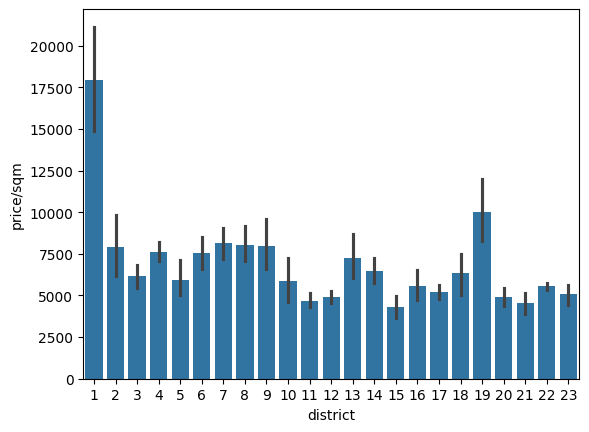

In [16]:
sns.barplot(x="district",y="price/sqm",data=num_cols)

### inputs for synthetic data gen

In [ ]:
#renaming for better handling
df = df.rename(columns={'price/sqm': 'price_per_sqm'})
df = df.rename(columns={'hohe räume': 'hohe_raeume'})

In [14]:
# Numeric distributions per district
numeric_stats = df.groupby('district')[['price_per_sqm', 'size', 'rooms']].agg(['mean', 'std'])

# Feature frequencies per district (binary columns)
feature_cols = ['altbau','balkon','dachterrasse','erstbezug','garten','hohe_raeume','klimaanlage','lift','loggia','terrasse', 'wintergarten']  # add all your binary cols
feature_freq = df.groupby('district')[feature_cols].mean()  # gives % with feature

# Seller type frequencies
seller_freq = df.groupby('district')['seller'].value_counts(normalize=True).unstack(fill_value=0)

## mapping it

In [15]:
#1. load geo data

url = "https://data.wien.gv.at/daten/geo?service=WFS&request=GetFeature&version=1.1.0&typeName=ogdwien:BEZIRKSGRENZEOGD&outputFormat=json"
gdf = gpd.read_file(url)
gdf.head()

#reproject to correct lat/lon
gdf = gdf.to_crs(epsg=4326)

In [16]:
# 2. Prepare price data from your df
district_prices = df.groupby('district')['price_per_sqm'].mean().reset_index()
district_prices['district'] = district_prices['district'].astype(int)
gdf['BEZNR'] = gdf['BEZNR'].astype(int)

In [17]:
# 3. Merge geo + price data
gdf_merged = gdf.merge(district_prices, left_on='BEZNR', right_on='district')

In [ ]:
pip install "folium>=0.12" matplotlib mapclassify

In [23]:
#4 create map and store in repo

m = gdf_merged.explore(
    column='price_per_sqm',
    cmap='YlOrRd',
    legend=True,
    tooltip=['price_per_sqm'],
    tiles='CartoDB positron'
)

# Add district number + price labels
for _, row in gdf_merged.iterrows():
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px; font-weight:bold; color:black">€{round(row["price_per_sqm"])}</div>'
        )
    ).add_to(m)

m.save('vienna_heatmap.html')

In [21]:
#outside area:
df['outside_area'] = (
    (df['terrasse'] == 1) |
    (df['balkon'] == 1) |
    (df['dachterrasse'] == 1) |
    (df['garten'] == 1) |
    (df['loggia'] == 1)
).astype(int)

In [24]:
outside_freq = df.groupby('district')['outside_area'].mean().reset_index()
outside_freq['outside_area'] = outside_freq['outside_area'].round(2)

In [25]:

gdf_merged2 = gdf.merge(outside_freq, left_on='BEZNR', right_on='district')
#gdf_merged2 = gdf_merged2.to_crs(epsg=4326) #we're doing that up top

In [26]:
m2 = gdf_merged2.explore(
    column='outside_area',
    cmap='YlOrRd',
    legend=True,
    tooltip=['outside_area'],
    tiles='CartoDB positron'
)

# Add district number + area labels
for _, row in gdf_merged2.iterrows():
    centroid = row.geometry.centroid
    folium.Marker(
        location=[centroid.y, centroid.x],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px; font-weight:bold; color:black">{row["outside_area"]:.0%}</div>'
        )
    ).add_to(m2)

m2.save('vienna_heatmap_outside_area.html')

## generator

### prep

In [27]:
#imports
from random import randint, random, gauss

In [28]:
numeric_stats.columns = ['_'.join(col) for col in numeric_stats.columns]
# gives you: price_per_sqm_mean, price_per_sqm_std, size_mean, size_std, rooms_mean, rooms_std

### covariance

In [29]:
cov_matrices = {}
for district in df['district'].unique():
    district_df = df[df['district'] == district][['size', 'rooms']]
    cov_matrices[district] = district_df.cov().values

### build

In [30]:
synthetic_rows = []

features = list(feature_freq.columns)  #all the binary features
sellers = list(seller_freq.columns)


for district in numeric_stats.index:
    mean_size  = numeric_stats.loc[district, 'size_mean']
    std_size   = numeric_stats.loc[district, 'size_std']
    mean_rooms = numeric_stats.loc[district, 'rooms_mean']
    std_rooms  = numeric_stats.loc[district, 'rooms_std']
    mean_price_per_sqm = numeric_stats.loc[district, 'price_per_sqm_mean']
    std_price_per_sqm = numeric_stats.loc[district, 'price_per_sqm_std']

    
    for _ in range(200):
        mean_vector = [mean_size, mean_rooms]
        cov = cov_matrices[district]

        while True:
            size, rooms = np.random.multivariate_normal(mean_vector, cov)
            size = round(size)
            if size >= 17:
                break

        rooms = max(round(rooms * 2) / 2, 1)
        max_rooms = size / 17
        rooms = max(round(min(rooms, max_rooms) * 2) / 2, 1)

        while True:
            price_per_sqm = round(gauss(mean_price_per_sqm, std_price_per_sqm))
            if price_per_sqm >= 500:
                break

        price = round(size * price_per_sqm / 500) * 500

        feature_dict = {f: int(np.random.rand() < feature_freq.loc[district, f]) for f in features}

        #seller_dict = {s: int(np.random.rand() < seller_freq.loc[district, s]) for s in sellers}
        p_commercial = seller_freq.loc[district, 'Commercial']
        seller = 'Commercial' if np.random.rand() < p_commercial else 'Private'
        
        synthetic_rows.append({
            'district': district,
            'size': size,
            'rooms': rooms,
            'price_per_sqm': price_per_sqm,
            'price': price,
             **feature_dict,        # unpacks all 11 feature columns
             'seller': seller
        })

df_synthetic = pd.DataFrame(synthetic_rows)

In [31]:
mean_price_per_sqm

np.float64(5085.746621160355)

In [32]:
df_synthetic.nlargest(10,"price")

,district,size,rooms,price_per_sqm,price,altbau,balkon,dachterrasse,erstbezug,garten,hohe_raeume,klimaanlage,lift,loggia,terrasse,wintergarten,seller
3581,18,643,9.0,9121,5865000,0,0,0,0,0,0,0,0,0,0,0,Commercial
128,1,194,6.5,30166,5852000,0,0,0,0,0,0,0,1,0,1,0,Commercial
97,1,190,5.5,26673,5068000,1,0,1,0,0,1,0,1,0,1,0,Commercial
3502,18,538,6.5,8735,4699500,0,0,0,0,0,0,0,1,0,0,0,Commercial
12,1,203,7.0,23116,4692500,1,0,0,0,0,0,0,0,0,1,0,Commercial
54,1,164,4.0,27784,4556500,0,0,0,0,0,0,0,0,0,0,0,Commercial
3541,18,501,8.0,9077,4547500,0,1,0,0,1,0,0,1,0,0,0,Commercial
72,1,221,6.5,18408,4068000,0,0,1,0,0,1,0,1,0,1,0,Commercial
182,1,180,6.0,22043,3967500,0,0,0,0,0,0,0,1,0,1,0,Commercial
175,1,157,5.0,24694,3877000,0,0,0,0,0,0,1,1,0,0,0,Commercial


In [33]:
# adding calculated columns:

df_synthetic['outside_area'] = df_synthetic[['terrasse', 'balkon', 'dachterrasse', 'garten', 'loggia']].max(axis=1)

In [34]:
df_synthetic['id'] = range(1, len(df_synthetic) + 1)
df_synthetic['title'] = df_synthetic['rooms'].astype(str) + '-Zimmer Wohnung, ' + df_synthetic['district'].astype(str) + '. Bezirk'

In [35]:
df_synthetic.describe().T

,count,mean,std,min,25%,50%,75%,max
district,4600.0,12.000000,6.633971,1.0,6.00,12.0,18.00,23.0
size,4600.0,83.454348,55.286465,17.0,53.00,73.0,98.00,643.0
rooms,4600.0,2.634891,1.079121,1.0,2.00,2.5,3.00,9.0
price_per_sqm,4600.0,6872.148261,3375.722626,567.0,4909.00,6030.0,7938.00,30166.0
price,4600.0,607672.500000,579593.409471,29000.0,277500.00,435000.0,698500.00,5865000.0
altbau,4600.0,0.193261,0.394899,0.0,0.00,0.0,0.00,1.0
balkon,4600.0,0.186522,0.389569,0.0,0.00,0.0,0.00,1.0
dachterrasse,4600.0,0.043696,0.204439,0.0,0.00,0.0,0.00,1.0
erstbezug,4600.0,0.092174,0.289303,0.0,0.00,0.0,0.00,1.0
garten,4600.0,0.068478,0.252592,0.0,0.00,0.0,0.00,1.0


### logic checks

In [36]:
#impossible combos:

df_synthetic[df_synthetic['rooms'] > df_synthetic['size'] / 17]

,district,size,rooms,price_per_sqm,price,altbau,balkon,dachterrasse,erstbezug,garten,hohe_raeume,klimaanlage,lift,loggia,terrasse,wintergarten,seller,outside_area,id,title
315,2,25,1.5,5697,142500,0,0,0,0,0,0,0,0,0,0,0,Commercial,0,316,"1.5-Zimmer Wohnung, 2. Bezirk"
398,2,32,2.0,9358,299500,0,0,0,0,0,0,0,0,0,0,0,Commercial,0,399,"2.0-Zimmer Wohnung, 2. Bezirk"
490,3,42,2.5,7193,302000,0,0,0,0,0,0,0,0,0,0,0,Private,0,491,"2.5-Zimmer Wohnung, 3. Bezirk"
509,3,42,2.5,6507,273500,1,0,0,0,0,0,0,0,0,0,0,Commercial,0,510,"2.5-Zimmer Wohnung, 3. Bezirk"
551,3,23,1.5,7271,167000,1,1,0,0,0,0,0,0,0,0,0,Commercial,1,552,"1.5-Zimmer Wohnung, 3. Bezirk"
907,5,25,1.5,3947,98500,0,0,0,0,0,0,0,0,0,1,0,Commercial,1,908,"1.5-Zimmer Wohnung, 5. Bezirk"
995,5,24,1.5,4657,112000,1,1,0,0,0,0,0,0,0,1,0,Commercial,1,996,"1.5-Zimmer Wohnung, 5. Bezirk"
1062,6,25,1.5,7535,188500,0,0,0,0,0,0,0,0,0,0,0,Commercial,0,1063,"1.5-Zimmer Wohnung, 6. Bezirk"
1216,7,23,1.5,6729,155000,0,0,0,0,0,0,0,1,0,0,0,Commercial,0,1217,"1.5-Zimmer Wohnung, 7. Bezirk"
1300,7,33,2.0,9347,308500,0,0,0,1,0,0,0,0,0,0,0,Commercial,0,1301,"2.0-Zimmer Wohnung, 7. Bezirk"


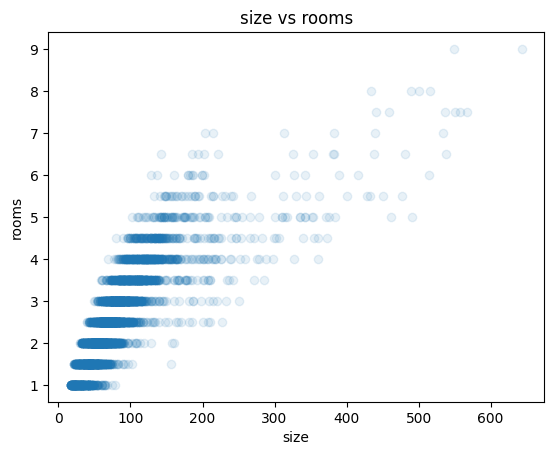

In [37]:
import matplotlib.pyplot as plt
plt.scatter(df_synthetic['size'], df_synthetic['rooms'], alpha=0.1)
plt.xlabel('size')
plt.ylabel('rooms')
plt.title('size vs rooms')
plt.show()

In [38]:
compare = df_synthetic.groupby('district')[['size', 'rooms', 'price_per_sqm']].mean()
compare.columns = ['synth_size', 'synth_rooms', 'synth_ppsqm']
compare['ref_size'] = numeric_stats['size_mean']
compare['ref_rooms'] = numeric_stats['rooms_mean']
compare['ref_ppsqm'] = numeric_stats['price_per_sqm_mean']
compare

,synth_size,synth_rooms,synth_ppsqm,ref_size,ref_rooms,ref_ppsqm
district,,,,,,
1,113.650,3.3450,18046.575,109.9,3.20,17919.594600
2,73.145,2.5600,7798.230,73.1,2.60,7927.195985
3,82.445,2.9725,6222.695,77.4,2.80,6190.406671
4,65.330,2.2225,7490.550,62.6,2.10,7612.626163
5,65.790,2.2050,5924.950,64.1,2.15,5922.539546
6,74.235,2.3150,7663.965,73.0,2.30,7574.838684
7,83.140,2.5825,8023.870,82.0,2.55,8149.767061
8,90.245,2.8800,7897.695,79.3,2.50,8030.901715
9,86.580,2.7500,8354.000,81.7,2.60,7982.347097


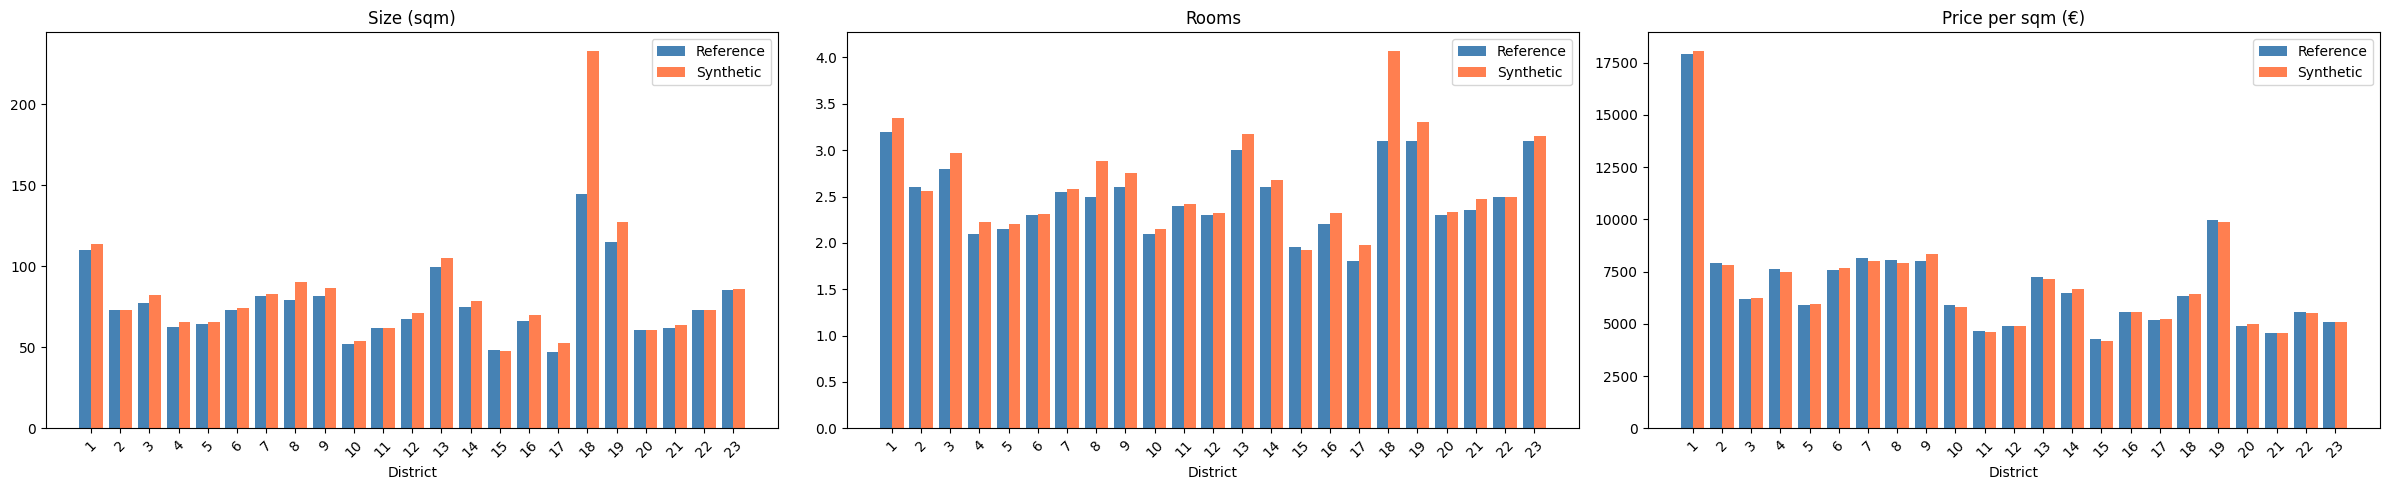

In [39]:
metrics = [
    ('ref_size', 'synth_size', 'Size (sqm)'),
    ('ref_rooms', 'synth_rooms', 'Rooms'),
    ('ref_ppsqm', 'synth_ppsqm', 'Price per sqm (€)')
]

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
districts = compare.index
x = range(len(districts))
width = 0.4

for ax, (ref_col, synth_col, label) in zip(axes, metrics):
    ax.bar([i - width/2 for i in x], compare[ref_col], width=width, label='Reference', color='steelblue')
    ax.bar([i + width/2 for i in x], compare[synth_col], width=width, label='Synthetic', color='coral')
    ax.set_title(label)
    ax.set_xlabel('District')
    ax.set_xticks(list(x))
    ax.set_xticklabels(districts, rotation=45)
    ax.legend()

plt.tight_layout()
plt.show()

In [40]:
compare.columns

Index(['synth_size', 'synth_rooms', 'synth_ppsqm', 'ref_size', 'ref_rooms',
       'ref_ppsqm'],
      dtype='str')

## anomaly injection

 ### DO NOT RE-RUN CELLS BELOW WITHOUT REGENERATING df_synthetic

In [41]:
#creating anomaly_type colums

df_synthetic['anomaly_type'] = ''

district_median_ppsqm = df_synthetic.groupby('district')['price_per_sqm'].median()

In [42]:
from random import uniform

In [43]:
#price per sqm

n_anomalies = int(len(df_synthetic) * 0.015)
anomaly_idx = df_synthetic.sample(n=n_anomalies, random_state=42).index

for idx in anomaly_idx:
    district = df_synthetic.loc[idx, 'district']
    median = district_median_ppsqm[district]
    
    new_ppsqm = uniform(median * 0.55, median * 0.65)  # 35-45% below median, uniform imported from random
    df_synthetic.loc[idx, 'price_per_sqm'] = round(new_ppsqm)
    df_synthetic.loc[idx, 'price'] = round(df_synthetic.loc[idx, 'size'] * new_ppsqm / 500) * 500
    df_synthetic.loc[idx, 'anomaly_type'] = 'low_price'

In [44]:
df_synthetic[df_synthetic['anomaly_type'] == 'low_price'].shape[0]

69

In [45]:
#implausible room number

n_anomalies = int(len(df_synthetic) * 0.015)
anomaly_idx = df_synthetic[df_synthetic['anomaly_type'] == ''].sample(n=n_anomalies, random_state=43).index

for idx in anomaly_idx:
    size = df_synthetic.loc[idx, 'size']
    max_plausible_rooms = size / 17
    
    implausible_rooms = round(uniform(max_plausible_rooms * 2, max_plausible_rooms * 3) * 2) / 2
    
    df_synthetic.loc[idx, 'rooms'] = implausible_rooms
    
    current = df_synthetic.loc[idx, 'anomaly_type']
    df_synthetic.loc[idx, 'anomaly_type'] = 'room_to_sqm' if current == '' else current + ',room_to_sqm'

In [46]:
#luxury features at low price points

luxury_features = ('balkon','klimaanlage','erstbezug','terrasse','dachterrasse','hohe_raeume')

In [47]:
lowest_ppsqm = df_synthetic.groupby('district')['price_per_sqm'].quantile(0.1)
n_anomalies = int(len(df_synthetic) * 0.015)
low_price_mask = df_synthetic.apply(
    lambda row: row['price_per_sqm'] <= lowest_ppsqm[row['district']], axis=1
)
anomaly_idx = df_synthetic[low_price_mask & (df_synthetic['anomaly_type'] == '')].sample(n=n_anomalies, random_state=44).index

for idx in anomaly_idx:
    district = df_synthetic.loc[idx, 'district']
    missing = [f for f in luxury_features if df_synthetic.loc[idx, f] == 0]

    to_add = list(np.random.choice(missing, size=min(2, len(missing)), replace=False))

    for f in to_add:
        df_synthetic.loc[idx,f] = 1
    
    current = df_synthetic.loc[idx, 'anomaly_type']
    df_synthetic.loc[idx, 'anomaly_type'] = 'luxury_features' if current == '' else current + ',luxury_features'

In [48]:
df_synthetic[df_synthetic['anomaly_type'].str.contains('luxury_features')].shape[0]

69

In [49]:
# erstbezug + low_price

n_anomalies = int(len(df_synthetic) * 0.015)
bottom_ppsqm = df_synthetic.groupby('district')['price_per_sqm'].quantile(0.25)
bottom_price_mask = df_synthetic.apply(
    lambda row: row['price_per_sqm'] <= bottom_ppsqm[row['district']], axis=1
)
anomaly_idx = df_synthetic[bottom_price_mask & (df_synthetic['anomaly_type'] == '')].sample(n=n_anomalies, random_state=45).index

for idx in anomaly_idx:
    df_synthetic.loc[idx, 'erstbezug'] = 1
    current = df_synthetic.loc[idx, 'anomaly_type']
    df_synthetic.loc[idx, 'anomaly_type'] = 'low_price_erstbezug' if current == '' else current + ',low_price_erstbezug'

In [50]:
#erstbezug + altbau
df_synthetic[(df_synthetic['altbau'] == 1) & (df_synthetic['erstbezug'] == 1)]

,district,size,rooms,price_per_sqm,price,altbau,balkon,dachterrasse,erstbezug,garten,...,klimaanlage,lift,loggia,terrasse,wintergarten,seller,outside_area,id,title,anomaly_type
19,1,120,3.5,18030,2163500,1,0,0,1,0,...,0,0,0,0,0,Commercial,0,20,"3.5-Zimmer Wohnung, 1. Bezirk",
20,1,147,5.0,22933,3371000,1,0,0,1,0,...,0,1,0,0,0,Commercial,0,21,"5.0-Zimmer Wohnung, 1. Bezirk",
23,1,106,4.0,11205,1187500,1,0,0,1,0,...,0,1,0,0,0,Commercial,0,24,"4.0-Zimmer Wohnung, 1. Bezirk",low_price
31,1,176,5.5,18089,3183500,1,0,0,1,0,...,0,0,0,0,0,Commercial,0,32,"5.5-Zimmer Wohnung, 1. Bezirk",
39,1,136,3.5,27669,3763000,1,0,0,1,0,...,0,0,0,1,0,Commercial,1,40,"3.5-Zimmer Wohnung, 1. Bezirk",
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3432,18,342,6.0,3042,1040500,1,0,0,1,0,...,0,0,0,1,0,Private,0,3433,"6.0-Zimmer Wohnung, 18. Bezirk",luxury_features
3492,18,96,2.0,4877,468000,1,0,0,1,0,...,0,0,0,0,0,Commercial,0,3493,"2.0-Zimmer Wohnung, 18. Bezirk",low_price_erstbezug
3524,18,207,5.0,4468,925000,1,0,0,1,0,...,0,0,0,0,0,Commercial,0,3525,"5.0-Zimmer Wohnung, 18. Bezirk",low_price_erstbezug
3820,20,55,2.0,4538,249500,1,0,0,1,0,...,0,0,0,0,0,Commercial,0,3821,"2.0-Zimmer Wohnung, 20. Bezirk",


In [51]:
mask = (df_synthetic['altbau'] == 1) & (df_synthetic['erstbezug'] == 1)
df_synthetic.loc[mask, 'anomaly_type'] = df_synthetic.loc[mask, 'anomaly_type'].apply(
    lambda x: 'altbau_erstbezug' if x == '' else x + ',altbau_erstbezug'
)

In [52]:
df_synthetic['anomaly_type'].value_counts()

anomaly_type
                                        4257
altbau_erstbezug                          67
room_to_sqm                               67
low_price                                 66
luxury_features                           60
low_price_erstbezug                       56
low_price_erstbezug,altbau_erstbezug      13
luxury_features,altbau_erstbezug           9
low_price,altbau_erstbezug                 3
room_to_sqm,altbau_erstbezug               2
Name: count, dtype: int64

In [ ]:
df_synthetic.to_pickle("data/synthetic_data.pkl")